**Health Care Appointment Data Set- Appointment No Show Analysis** 

In [1]:
import pandas as pd

In [2]:
data = pd.read_csv("synthetic_healthcare_appointment_no_show.csv")

In [3]:
data.head()

,appointment_id,patient_id,age,gender,city,neighborhood,scheduled_day,appointment_day,waiting_days,appointment_hour,...,temperature_celsius,rainy_day,employment_status,education_level,income_level,marital_status,children_count,patient_satisfaction_score,no_show_probability,no_show
0,APT-100000,PAT-25795,42,Female,Almere,East,2024-07-10,2024-07-14,4,8,...,15.3,0,Employed,Secondary,Middle,Single,0,6.9,0.0319,0
1,APT-100001,PAT-10860,9,Male,Groningen,West,2024-01-21,2024-02-07,17,12,...,13.9,0,Retired,Secondary,Middle,Married,1,4.7,0.0559,0
2,APT-100002,PAT-86820,27,Female,Utrecht,East,2025-09-06,2025-09-08,2,14,...,3.5,0,Employed,Secondary,Middle,Single,2,9.5,0.0201,0
3,APT-100003,PAT-64886,0,Female,The Hague,Rural,2024-01-24,2024-02-04,11,10,...,18.5,0,Unemployed,Secondary,Lower-Middle,Divorced,0,5.8,0.0627,1
4,APT-100004,PAT-16265,39,Male,Almere,Suburban,2025-03-27,2025-04-13,17,10,...,1.8,0,Student,NaN,NaN,Divorced,0,NaN,0.0792,1


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 39 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   appointment_id              50000 non-null  str    
 1   patient_id                  50000 non-null  str    
 2   age                         50000 non-null  int64  
 3   gender                      50000 non-null  str    
 4   city                        50000 non-null  str    
 5   neighborhood                50000 non-null  str    
 6   scheduled_day               50000 non-null  str    
 7   appointment_day             50000 non-null  str    
 8   waiting_days                50000 non-null  int64  
 9   appointment_hour            50000 non-null  int64  
 10  day_of_week                 50000 non-null  str    
 11  month                       50000 non-null  int64  
 12  sms_received                50000 non-null  int64  
 13  reminder_calls              50000 non-null

In [5]:
data.columns

Index(['appointment_id', 'patient_id', 'age', 'gender', 'city', 'neighborhood',
       'scheduled_day', 'appointment_day', 'waiting_days', 'appointment_hour',
       'day_of_week', 'month', 'sms_received', 'reminder_calls',
       'previous_appointments', 'previous_no_shows', 'no_show_rate',
       'distance_km', 'transportation_type', 'insurance_type',
       'has_chronic_disease', 'hypertension', 'diabetes', 'alcoholism',
       'disability', 'appointment_type', 'doctor_specialty', 'clinic_type',
       'weather_condition', 'temperature_celsius', 'rainy_day',
       'employment_status', 'education_level', 'income_level',
       'marital_status', 'children_count', 'patient_satisfaction_score',
       'no_show_probability', 'no_show'],
      dtype='str')

no_show - column if patient attended '0' if patient missed attendence '1' 

In [6]:
data['no_show']

0        0
1        0
2        0
3        1
4        1
        ..
49995    0
49996    1
49997    0
49998    0
49999    0
Name: no_show, Length: 50000, dtype: int64

**Handling Null Values & Duplicates Rows**

In [7]:
print(data.duplicated().sum())

0


In [8]:
print(data.loc[0])

appointment_id                      APT-100000
patient_id                           PAT-25795
age                                         42
gender                                  Female
city                                    Almere
neighborhood                              East
scheduled_day                       2024-07-10
appointment_day                     2024-07-14
waiting_days                                 4
appointment_hour                             8
day_of_week                             Sunday
month                                        7
sms_received                                 1
reminder_calls                               0
previous_appointments                        7
previous_no_shows                            2
no_show_rate                             0.286
distance_km                               8.69
transportation_type           Public Transport
insurance_type                          Public
has_chronic_disease                          1
hypertension 

In [9]:
print(pd.options.display.max_rows)

60


In [10]:
print(data.loc[500, 'city'])

Groningen


In [11]:
df = data

In [12]:
print(df.duplicated().sum())

0


In [13]:
print(df.isna().sum())

appointment_id                   0
patient_id                       0
age                              0
gender                           0
city                             0
neighborhood                     0
scheduled_day                    0
appointment_day                  0
waiting_days                     0
appointment_hour                 0
day_of_week                      0
month                            0
sms_received                     0
reminder_calls                   0
previous_appointments            0
previous_no_shows                0
no_show_rate                     0
distance_km                      0
transportation_type           1250
insurance_type                 750
has_chronic_disease              0
hypertension                     0
diabetes                         0
alcoholism                       0
disability                       0
appointment_type                 0
doctor_specialty                 0
clinic_type                      0
weather_condition   

In [14]:
# calculate the percentage of null values
missing_perc = (df.isna().sum() / len(df) * 100)
print(missing_perc[missing_perc > 0].sort_values(ascending=False))

income_level                  4.0
education_level               3.0
transportation_type           2.5
patient_satisfaction_score    2.0
insurance_type                1.5
dtype: float64


In [15]:
df.fillna({'transportation_type':'Unknown'}, inplace=True)
df.fillna({'insurance_type':'Unknown'}, inplace=True)
df.fillna({'education_level':'Unknown'}, inplace=True)

,appointment_id,patient_id,age,gender,city,neighborhood,scheduled_day,appointment_day,waiting_days,appointment_hour,...,temperature_celsius,rainy_day,employment_status,education_level,income_level,marital_status,children_count,patient_satisfaction_score,no_show_probability,no_show
0,APT-100000,PAT-25795,42,Female,Almere,East,2024-07-10,2024-07-14,4,8,...,15.3,0,Employed,Secondary,Middle,Single,0,6.9,0.0319,0
1,APT-100001,PAT-10860,9,Male,Groningen,West,2024-01-21,2024-02-07,17,12,...,13.9,0,Retired,Secondary,Middle,Married,1,4.7,0.0559,0
2,APT-100002,PAT-86820,27,Female,Utrecht,East,2025-09-06,2025-09-08,2,14,...,3.5,0,Employed,Secondary,Middle,Single,2,9.5,0.0201,0
3,APT-100003,PAT-64886,0,Female,The Hague,Rural,2024-01-24,2024-02-04,11,10,...,18.5,0,Unemployed,Secondary,Lower-Middle,Divorced,0,5.8,0.0627,1
4,APT-100004,PAT-16265,39,Male,Almere,Suburban,2025-03-27,2025-04-13,17,10,...,1.8,0,Student,Unknown,NaN,Divorced,0,NaN,0.0792,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,APT-149995,PAT-77722,18,Male,Rotterdam,East,2025-11-26,2025-12-10,14,13,...,21.0,0,Student,Vocational,Middle,Single,0,10.0,0.0331,0
49996,APT-149996,PAT-54279,10,Male,Eindhoven,North,2024-02-05,2024-02-19,14,8,...,8.7,0,Employed,Vocational,Upper-Middle,Married,2,7.8,0.0390,1
49997,APT-149997,PAT-19398,27,Male,Amsterdam,Suburban,2025-05-18,2025-06-18,31,14,...,12.8,0,Employed,Vocational,Middle,Single,2,3.5,0.1165,0
49998,APT-149998,PAT-71140,41,Male,Utrecht,North,2024-06-04,2024-07-25,51,12,...,33.0,1,Unemployed,Vocational,Middle,Married,0,7.5,0.2014,0


In [16]:
print("transportation_type:",df["transportation_type"].isna().sum())
print("insurance_type:",df["insurance_type"].isna().sum())
print("education_level:",df["education_level"].isna().sum())

transportation_type: 0
insurance_type: 0
education_level: 0


In [17]:
# Check if null handled correctly
print("Unknown transportation_type:",(df["transportation_type"] == 'Unknown').sum())
print("Unknown insurance_type:",(df["insurance_type"] == 'Unknown').sum())
print("Unknown education_level:",(df["education_level"] == 'Unknown').sum())

Unknown transportation_type: 1250
Unknown insurance_type: 750
Unknown education_level: 1500


In [18]:
df['income_level'].describe()


count      48000
unique         5
top       Middle
freq       16265
Name: income_level, dtype: object

In [19]:
print((df['income_level'].value_counts() / len(df)) *100)

income_level
Middle          32.530
Lower-Middle    23.166
Low             17.360
Upper-Middle    17.328
High             5.616
Name: count, dtype: float64


In [20]:
df.fillna({'income_level':'Unknown'}, inplace=True)

,appointment_id,patient_id,age,gender,city,neighborhood,scheduled_day,appointment_day,waiting_days,appointment_hour,...,temperature_celsius,rainy_day,employment_status,education_level,income_level,marital_status,children_count,patient_satisfaction_score,no_show_probability,no_show
0,APT-100000,PAT-25795,42,Female,Almere,East,2024-07-10,2024-07-14,4,8,...,15.3,0,Employed,Secondary,Middle,Single,0,6.9,0.0319,0
1,APT-100001,PAT-10860,9,Male,Groningen,West,2024-01-21,2024-02-07,17,12,...,13.9,0,Retired,Secondary,Middle,Married,1,4.7,0.0559,0
2,APT-100002,PAT-86820,27,Female,Utrecht,East,2025-09-06,2025-09-08,2,14,...,3.5,0,Employed,Secondary,Middle,Single,2,9.5,0.0201,0
3,APT-100003,PAT-64886,0,Female,The Hague,Rural,2024-01-24,2024-02-04,11,10,...,18.5,0,Unemployed,Secondary,Lower-Middle,Divorced,0,5.8,0.0627,1
4,APT-100004,PAT-16265,39,Male,Almere,Suburban,2025-03-27,2025-04-13,17,10,...,1.8,0,Student,Unknown,Unknown,Divorced,0,NaN,0.0792,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,APT-149995,PAT-77722,18,Male,Rotterdam,East,2025-11-26,2025-12-10,14,13,...,21.0,0,Student,Vocational,Middle,Single,0,10.0,0.0331,0
49996,APT-149996,PAT-54279,10,Male,Eindhoven,North,2024-02-05,2024-02-19,14,8,...,8.7,0,Employed,Vocational,Upper-Middle,Married,2,7.8,0.0390,1
49997,APT-149997,PAT-19398,27,Male,Amsterdam,Suburban,2025-05-18,2025-06-18,31,14,...,12.8,0,Employed,Vocational,Middle,Single,2,3.5,0.1165,0
49998,APT-149998,PAT-71140,41,Male,Utrecht,North,2024-06-04,2024-07-25,51,12,...,33.0,1,Unemployed,Vocational,Middle,Married,0,7.5,0.2014,0


In [21]:
#Check null handled correctly
print("income_level:",df["income_level"].isna().sum())

income_level: 0


In [22]:
df['patient_satisfaction_score'].describe()

count    49000.000000
mean         7.161353
std          1.702779
min          1.000000
25%          6.000000
50%          7.200000
75%          8.400000
max         10.000000
Name: patient_satisfaction_score, dtype: float64

In [23]:
import matplotlib.pyplot as plt

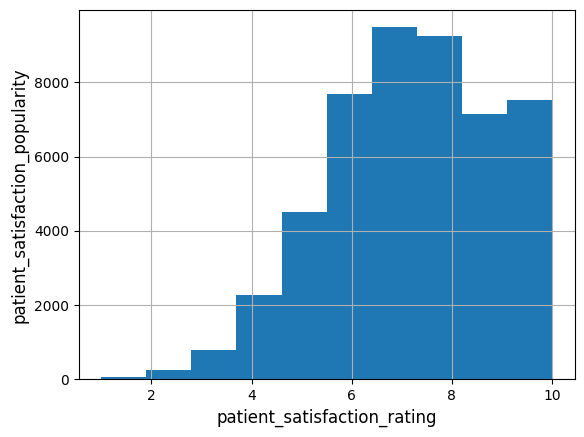

In [24]:
df['patient_satisfaction_score'].hist()
plt.xlabel("patient_satisfaction_rating", fontsize=12)
plt.ylabel("patient_satisfaction_popularity", fontsize=12)
plt.show()

In [25]:
df.fillna({'patient_satisfaction_score': df['patient_satisfaction_score'].mean()}, inplace=True)

,appointment_id,patient_id,age,gender,city,neighborhood,scheduled_day,appointment_day,waiting_days,appointment_hour,...,temperature_celsius,rainy_day,employment_status,education_level,income_level,marital_status,children_count,patient_satisfaction_score,no_show_probability,no_show
0,APT-100000,PAT-25795,42,Female,Almere,East,2024-07-10,2024-07-14,4,8,...,15.3,0,Employed,Secondary,Middle,Single,0,6.900000,0.0319,0
1,APT-100001,PAT-10860,9,Male,Groningen,West,2024-01-21,2024-02-07,17,12,...,13.9,0,Retired,Secondary,Middle,Married,1,4.700000,0.0559,0
2,APT-100002,PAT-86820,27,Female,Utrecht,East,2025-09-06,2025-09-08,2,14,...,3.5,0,Employed,Secondary,Middle,Single,2,9.500000,0.0201,0
3,APT-100003,PAT-64886,0,Female,The Hague,Rural,2024-01-24,2024-02-04,11,10,...,18.5,0,Unemployed,Secondary,Lower-Middle,Divorced,0,5.800000,0.0627,1
4,APT-100004,PAT-16265,39,Male,Almere,Suburban,2025-03-27,2025-04-13,17,10,...,1.8,0,Student,Unknown,Unknown,Divorced,0,7.161353,0.0792,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,APT-149995,PAT-77722,18,Male,Rotterdam,East,2025-11-26,2025-12-10,14,13,...,21.0,0,Student,Vocational,Middle,Single,0,10.000000,0.0331,0
49996,APT-149996,PAT-54279,10,Male,Eindhoven,North,2024-02-05,2024-02-19,14,8,...,8.7,0,Employed,Vocational,Upper-Middle,Married,2,7.800000,0.0390,1
49997,APT-149997,PAT-19398,27,Male,Amsterdam,Suburban,2025-05-18,2025-06-18,31,14,...,12.8,0,Employed,Vocational,Middle,Single,2,3.500000,0.1165,0
49998,APT-149998,PAT-71140,41,Male,Utrecht,North,2024-06-04,2024-07-25,51,12,...,33.0,1,Unemployed,Vocational,Middle,Married,0,7.500000,0.2014,0


In [26]:
# Check if null handled correctly
print("patient_satisfaction_score:",df["patient_satisfaction_score"].isna().sum())

patient_satisfaction_score: 0


In [27]:
df.isna().sum()

appointment_id                0
patient_id                    0
age                           0
gender                        0
city                          0
neighborhood                  0
scheduled_day                 0
appointment_day               0
waiting_days                  0
appointment_hour              0
day_of_week                   0
month                         0
sms_received                  0
reminder_calls                0
previous_appointments         0
previous_no_shows             0
no_show_rate                  0
distance_km                   0
transportation_type           0
insurance_type                0
has_chronic_disease           0
hypertension                  0
diabetes                      0
alcoholism                    0
disability                    0
appointment_type              0
doctor_specialty              0
clinic_type                   0
weather_condition             0
temperature_celsius           0
rainy_day                     0
employme

**Patient Behavior Analysis**

In [28]:
pdf = df

In [29]:
pdf.columns

Index(['appointment_id', 'patient_id', 'age', 'gender', 'city', 'neighborhood',
       'scheduled_day', 'appointment_day', 'waiting_days', 'appointment_hour',
       'day_of_week', 'month', 'sms_received', 'reminder_calls',
       'previous_appointments', 'previous_no_shows', 'no_show_rate',
       'distance_km', 'transportation_type', 'insurance_type',
       'has_chronic_disease', 'hypertension', 'diabetes', 'alcoholism',
       'disability', 'appointment_type', 'doctor_specialty', 'clinic_type',
       'weather_condition', 'temperature_celsius', 'rainy_day',
       'employment_status', 'education_level', 'income_level',
       'marital_status', 'children_count', 'patient_satisfaction_score',
       'no_show_probability', 'no_show'],
      dtype='str')

In [30]:
patient_columns = ['age', 'gender', 'city', 'neighborhood',
       'appointment_day', 'waiting_days', 'appointment_hour', 'employment_status', 'education_level', 'income_level',
       'marital_status', 'children_count', 'patient_satisfaction_score',
       'no_show']

In [31]:
pdf = pdf[patient_columns]

In [32]:
pdf.head(10)

,age,gender,city,neighborhood,appointment_day,waiting_days,appointment_hour,employment_status,education_level,income_level,marital_status,children_count,patient_satisfaction_score,no_show
0,42,Female,Almere,East,2024-07-14,4,8,Employed,Secondary,Middle,Single,0,6.900000,0
1,9,Male,Groningen,West,2024-02-07,17,12,Retired,Secondary,Middle,Married,1,4.700000,0
2,27,Female,Utrecht,East,2025-09-08,2,14,Employed,Secondary,Middle,Single,2,9.500000,0
3,0,Female,The Hague,Rural,2024-02-04,11,10,Unemployed,Secondary,Lower-Middle,Divorced,0,5.800000,1
4,39,Male,Almere,Suburban,2025-04-13,17,10,Student,Unknown,Unknown,Divorced,0,7.161353,1
5,37,Male,Eindhoven,North,2024-05-04,9,16,Unemployed,Bachelor,Lower-Middle,Married,0,6.600000,0
6,37,Male,Rotterdam,Suburban,2024-08-06,6,15,Employed,Vocational,Middle,Married,2,7.100000,0
7,35,Male,Groningen,Suburban,2024-06-15,11,12,Retired,Primary,Lower-Middle,Single,1,9.100000,0
8,55,Male,Almere,Central,2024-10-10,7,7,Retired,Secondary,Upper-Middle,Single,1,5.700000,0
9,79,Female,The Hague,South,2025-08-04,19,11,Unemployed,Bachelor,Upper-Middle,Married,0,8.700000,1


Row Trasformation & Datatype handling

In [33]:
# fixing age = 0
print("count:",(pdf['age'] == 0).sum())
print("perc:",(pdf['age'] == 0).sum()/len(pdf))
invalid_age = pdf['age'] <= 0
print(pdf[invalid_age])

count: 1594
perc: 0.03188
       age  gender       city neighborhood appointment_day  waiting_days  \
3        0  Female  The Hague        Rural      2024-02-04            11   
31       0  Female  The Hague        North      2025-06-15            12   
48       0  Female  Eindhoven         East      2025-11-17            16   
140      0    Male  Groningen      Central      2024-10-28            11   
143      0  Female  Rotterdam        South      2024-11-28            16   
...    ...     ...        ...          ...             ...           ...   
49885    0    Male  Rotterdam      Central      2025-03-21            16   
49887    0  Female    Utrecht        Rural      2025-02-03            13   
49899    0  Female  Eindhoven         West      2025-12-03            11   
49961    0    Male  Eindhoven        North      2024-11-23             6   
49984    0  Female  Groningen      Central      2024-08-27            17   

       appointment_hour employment_status education_level  in

In [34]:
pdf[pdf['age'] == 0][[ 
    'age',
    'marital_status',
    'employment_status',
    'children_count'
    ]].head(15)

,age,marital_status,employment_status,children_count
3,0,Divorced,Unemployed,0
31,0,Married,Retired,0
48,0,Single,Employed,3
140,0,Married,Unemployed,0
143,0,Single,Retired,0
156,0,Married,Employed,4
160,0,Single,Unemployed,1
166,0,Single,Employed,1
185,0,Single,Employed,0
190,0,Single,Employed,2


In [35]:
pdf.loc[pdf['age'] == 0, 'age'] = pd.NA

In [36]:
pdf['age']

0        42.0
1         9.0
2        27.0
3         NaN
4        39.0
         ... 
49995    18.0
49996    10.0
49997    27.0
49998    41.0
49999    43.0
Name: age, Length: 50000, dtype: float64

In [37]:
print("Sum of Null Values:",pdf['age'].isna().sum())

Sum of Null Values: 1594


In [38]:
pdf['age'].describe()

count    48406.000000
mean        42.986510
std         20.173051
min          1.000000
25%         28.000000
50%         42.000000
75%         57.000000
max         95.000000
Name: age, dtype: float64

In [39]:
pdf.fillna(pdf['age'].median(), inplace=True)

,age,gender,city,neighborhood,appointment_day,waiting_days,appointment_hour,employment_status,education_level,income_level,marital_status,children_count,patient_satisfaction_score,no_show
0,42.0,Female,Almere,East,2024-07-14,4,8,Employed,Secondary,Middle,Single,0,6.900000,0
1,9.0,Male,Groningen,West,2024-02-07,17,12,Retired,Secondary,Middle,Married,1,4.700000,0
2,27.0,Female,Utrecht,East,2025-09-08,2,14,Employed,Secondary,Middle,Single,2,9.500000,0
3,42.0,Female,The Hague,Rural,2024-02-04,11,10,Unemployed,Secondary,Lower-Middle,Divorced,0,5.800000,1
4,39.0,Male,Almere,Suburban,2025-04-13,17,10,Student,Unknown,Unknown,Divorced,0,7.161353,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,18.0,Male,Rotterdam,East,2025-12-10,14,13,Student,Vocational,Middle,Single,0,10.000000,0
49996,10.0,Male,Eindhoven,North,2024-02-19,14,8,Employed,Vocational,Upper-Middle,Married,2,7.800000,1
49997,27.0,Male,Amsterdam,Suburban,2025-06-18,31,14,Employed,Vocational,Middle,Single,2,3.500000,0
49998,41.0,Male,Utrecht,North,2024-07-25,51,12,Unemployed,Vocational,Middle,Married,0,7.500000,0


In [40]:
# Age invalid factors below 18
print("age below 18, marital_status:",((pdf['age'] < 18) & (pdf['marital_status'].isin(["Married","Divorced","Widowed"]))).sum())
print("age below 18, having childern:",((pdf['age'] < 18) & (pdf['children_count'] > 0)).sum())
print("age below 18, and retired:",((pdf['age'] < 18) & (pdf['employment_status'].isin(["Retired"]))).sum())

age below 18, marital_status: 3337
age below 18, having childern: 3294
age below 18, and retired: 905


In [41]:
pdf['age'].value_counts().head(15)

age
42.0    2522
39.0     937
46.0     931
41.0     931
38.0     917
40.0     908
45.0     902
48.0     901
43.0     889
47.0     888
44.0     872
51.0     870
49.0     859
36.0     857
35.0     855
Name: count, dtype: int64

In [42]:
# gender column data check
print(pdf['gender'].unique())

<StringArray>
['Female', 'Male', 'Other']
Length: 3, dtype: str


In [43]:
gender_prec = (pdf['gender'].value_counts() / len(pdf))*100
print(pdf['gender'].value_counts(),gender_prec) 

gender
Female    26119
Male      22908
Other       973
Name: count, dtype: int64 gender
Female    52.238
Male      45.816
Other      1.946
Name: count, dtype: float64


In [44]:
print("Sum of gender Null Values:", pdf['gender'].isna().sum())

Sum of gender Null Values: 0


In [45]:
# city column data check
print(pdf['city'].unique())

<StringArray>
[   'Almere', 'Groningen',   'Utrecht', 'The Hague', 'Eindhoven', 'Rotterdam',
 'Amsterdam',   'Tilburg']
Length: 8, dtype: str


In [46]:
city_prec = (pdf['city'].value_counts()/ len(pdf))*100
print(city_prec)

city
Amsterdam    17.880
Rotterdam    16.004
The Hague    13.962
Utrecht      12.832
Eindhoven    12.184
Almere        9.084
Tilburg       9.050
Groningen     9.004
Name: count, dtype: float64


In [47]:
# neighborhood column data check
print(pdf['neighborhood'].unique())

<StringArray>
['East', 'West', 'Rural', 'Suburban', 'North', 'Central', 'South']
Length: 7, dtype: str


In [48]:
neigh_prec = (pdf['neighborhood'].value_counts() / len(pdf))*100
print(neigh_prec)

neighborhood
Suburban    18.162
Central     18.022
West        14.006
East        13.868
North       13.000
South       12.916
Rural       10.026
Name: count, dtype: float64


In [49]:
# appointment_day column datatype check
print(pdf['appointment_day'].dtypes)

str


In [50]:
pdf.dtypes

age                           float64
gender                            str
city                              str
neighborhood                      str
appointment_day                   str
waiting_days                    int64
appointment_hour                int64
employment_status                 str
education_level                   str
income_level                      str
marital_status                    str
children_count                  int64
patient_satisfaction_score    float64
no_show                         int64
dtype: object

In [51]:
# Change datatype str to datetime(us)
pdf['appointment_day'] = pd.to_datetime(pdf['appointment_day'])

In [52]:
pdf['appointment_day'].dtypes

dtype('<M8[us]')

In [53]:
pdf['appointment_day']

0       2024-07-14
1       2024-02-07
2       2025-09-08
3       2024-02-04
4       2025-04-13
           ...    
49995   2025-12-10
49996   2024-02-19
49997   2025-06-18
49998   2024-07-25
49999   2024-04-23
Name: appointment_day, Length: 50000, dtype: datetime64[us]

In [54]:
# employment_status	column data check
employemnt_status_val = pdf['employment_status'].unique()
pdf['employment_status'].unique()

<StringArray>
['Employed', 'Retired', 'Unemployed', 'Student', 'Self-employed']
Length: 5, dtype: str

In [55]:
employment_status_perc = (pdf['employment_status'].value_counts() / len(pdf))*100
print(employment_status_perc)


employment_status
Employed         46.332
Retired          17.880
Unemployed       13.796
Student          12.148
Self-employed     9.844
Name: count, dtype: float64


In [56]:
# education_level column data check
pdf['education_level'].unique()

<StringArray>
['Secondary', 'Unknown', 'Bachelor', 'Vocational', 'Primary', 'Master', 'PhD']
Length: 7, dtype: str

In [57]:
edu_perc = (pdf['education_level'].value_counts()/ len(pdf))*100
print(edu_perc)

education_level
Secondary     26.850
Vocational    23.348
Bachelor      22.146
Primary       11.838
Master        10.778
Unknown        3.000
PhD            2.040
Name: count, dtype: float64


In [58]:
# income_level column data check
print(pdf['income_level'].unique())

<StringArray>
['Middle', 'Lower-Middle', 'Unknown', 'Upper-Middle', 'Low', 'High']
Length: 6, dtype: str


In [59]:
income_perc = (pdf['income_level'].value_counts()/ len(pdf))*100
print(income_perc)

income_level
Middle          32.530
Lower-Middle    23.166
Low             17.360
Upper-Middle    17.328
High             5.616
Unknown          4.000
Name: count, dtype: float64


In [60]:
pdf.isna().sum()

age                           0
gender                        0
city                          0
neighborhood                  0
appointment_day               0
waiting_days                  0
appointment_hour              0
employment_status             0
education_level               0
income_level                  0
marital_status                0
children_count                0
patient_satisfaction_score    0
no_show                       0
dtype: int64

In [61]:
# marital_status column data check
print(pdf['marital_status'].unique())

<StringArray>
['Single', 'Married', 'Divorced', 'Widowed']
Length: 4, dtype: str


In [62]:
marital_status_perc = (pdf['marital_status'].value_counts() / len(pdf))*100
print(marital_status_perc)

marital_status
Married     43.224
Single      37.766
Divorced    12.052
Widowed      6.958
Name: count, dtype: float64


**Bivariate Patient Analysis Columns Vs No_show**

In [63]:
pdf['age_group'] = pd.cut(
    pdf['age'],
    bins = [0,18,35,50,65,100],
    labels = ['0-18','18-35', '35-50', '50-65', '65-100']
)
ans = pd.crosstab(pdf['age_group'], pdf['no_show'])
anss = pd.crosstab(pdf['age_group'], pdf['no_show'], normalize='index') * 100
ans[['0_pct', '1_pct']] = anss.round(2)

In [64]:
view_ans = ans.copy()
view_ans[['0_pct', '1_pct']] = view_ans[['0_pct', '1_pct']].astype(str) + '%'
view_ans

no_show,0,1,0_pct,1_pct
age_group,,,,
0-18,5307,487,91.59%,8.41%
18-35,11245,1016,91.71%,8.29%
35-50,13812,1207,91.96%,8.04%
50-65,9214,843,91.62%,8.38%
65-100,6284,585,91.48%,8.52%


In [65]:
#Gender_vs_no_show
gns = (pd.crosstab(pdf['gender'], pdf['no_show'], normalize='index') * 100).round(2)
gns.astype(str) + "%"

no_show,0,1
gender,,
Female,91.57%,8.43%
Male,91.92%,8.08%
Other,91.26%,8.74%


In [66]:
cns = pd.crosstab(pdf['city'], pdf['no_show'])


In [67]:
cnss = (pd.crosstab(pdf['city'], pdf['no_show'], normalize='index')) * 100
cns[['0_pct', '1_pct']] = cnss.round(2)
view_cns = cns.copy()
view_cns[['0_pct', '1_pct']] = view_cns[['0_pct', '1_pct']].astype(str) + '%'
view_cns


no_show,0,1,0_pct,1_pct
city,,,,
Almere,4154,388,91.46%,8.54%
Amsterdam,8223,717,91.98%,8.02%
Eindhoven,5598,494,91.89%,8.11%
Groningen,4116,386,91.43%,8.57%
Rotterdam,7361,641,91.99%,8.01%
The Hague,6392,589,91.56%,8.44%
Tilburg,4126,399,91.18%,8.82%
Utrecht,5892,524,91.83%,8.17%


In [68]:
nns = pd.crosstab(pdf['neighborhood'], pdf['no_show']) 
nnss = pd.crosstab(pdf['neighborhood'], pdf['no_show'], normalize='index') *100
nns[['0_pct','1_pct']] = nnss.round(2)
nns
view_nns = nns.copy()
view_nns[['0_pct','1_pct']] = view_nns[['0_pct','1_pct']].astype(str) + '%'
view_nns

no_show,0,1,0_pct,1_pct
neighborhood,,,,
Central,8256,755,91.62%,8.38%
East,6351,583,91.59%,8.41%
North,5995,505,92.23%,7.77%
Rural,4593,420,91.62%,8.38%
South,5932,526,91.86%,8.14%
Suburban,8286,795,91.25%,8.75%
West,6449,554,92.09%,7.91%


In [69]:
appoint_day_no_show = pd.crosstab(pdf['appointment_day'], pdf['no_show'])
appoint_day_no_show.reset_index(inplace=True)



In [70]:
appoint_day_no_show['day'] = appoint_day_no_show['appointment_day'].dt.day
appoint_day_no_show.head(10)

no_show,appointment_day,0,1,day
0,2024-01-01,59,7,1
1,2024-01-02,62,4,2
2,2024-01-03,57,8,3
3,2024-01-04,68,10,4
4,2024-01-05,79,6,5
5,2024-01-06,64,4,6
6,2024-01-07,70,4,7
7,2024-01-08,67,7,8
8,2024-01-09,61,9,9
9,2024-01-10,65,9,10


In [71]:
dns = appoint_day_no_show[['day', 0, 1]]
result = dns.groupby('day')[[0,1]].sum().assign(total = lambda x: x[0]+x[1]).sort_values(by=1, ascending=False)
result['1_pct'] = ((result[1] / result['total']) * 100).round(2)
result.columns = ['show', 'no_show', 'total', '1_pct']
result.columns.name = 'no_show_over_year'
dns = result.sort_index()

view_dns = dns.copy()
view_dns.sort_index()



no_show_over_year,show,no_show,total,1_pct
day,,,,
1,1516,157,1673,9.38
2,1517,130,1647,7.89
3,1509,139,1648,8.43
4,1481,135,1616,8.35
5,1486,150,1636,9.17
6,1481,111,1592,6.97
7,1502,152,1654,9.19
8,1490,147,1637,8.98
9,1483,144,1627,8.85


In [72]:
wnss = pd.crosstab(pdf['waiting_days'], pdf['no_show'])

wnss['total'] = wnss[[0,1]].sum(axis=1) 
wnss[['0_pct', '1_pct']] = (wnss[[0, 1]].div(wnss['total'], axis=0) * 100).round(2).astype(str) + "%"

wnss.sort_values(by='1_pct',ascending=False).head(20)

no_show,0,1,total,0_pct,1_pct
waiting_days,,,,,
28,382,42,424,90.09%,9.91%
19,1106,121,1227,90.14%,9.86%
23,711,77,788,90.23%,9.77%
22,806,85,891,90.46%,9.54%
45,50,5,55,90.91%,9.09%
17,1394,139,1533,90.93%,9.07%
12,2038,203,2241,90.94%,9.06%
14,1787,176,1963,91.03%,8.97%
20,949,90,1039,91.34%,8.66%


In [73]:
pdf['waiting_group'] = pd.cut(
    pdf['waiting_days'],
    bins = [0,7,14,21,30,60,180],
    labels=['0-7', '8-14', '15-21', '22-30', '31-60', '61+'],
    include_lowest=True
)


In [74]:
result = pd.crosstab(
    pdf['waiting_group'],
    pdf['no_show'],
    normalize='index'
) * 100

wns = result.round(2)
wns
view_wns = wns.copy()
view_wns[[0,1]] = view_wns[[0,1]].astype(str) +'%'
view_wns

no_show,0,1
waiting_group,,
0-7,94.09%,5.91%
8-14,92.11%,7.89%
15-21,90.52%,9.48%
22-30,88.39%,11.61%
31-60,84.68%,15.32%
61+,70.0%,30.0%


In [75]:
pd.crosstab(
    pdf['waiting_group'],
    pdf['no_show'])

no_show,0,1
waiting_group,,
0-7,15434,969
8-14,15420,1320
15-21,8503,891
22-30,4522,594
31-60,1962,355
61+,21,9


In [76]:
pdf['appointment_hour'].sort_values()

20243     7
41477     7
49540     7
2116      7
2114      7
         ..
41015    18
41010    18
40969    18
102      18
98       18
Name: appointment_hour, Length: 50000, dtype: int64

In [77]:
pdf['appointment_hour_group'] = pd.cut(
    pdf['appointment_hour'],
    bins = [6,12,17,21],
    labels=['6Am-12Am', '12Pm-5Pm', '5pm-9Pm'],
    include_lowest=True
)

In [78]:
ahg = pd.crosstab(pdf['appointment_hour_group'],pdf['no_show'])
ahgg = pd.crosstab(pdf['appointment_hour_group'],pdf['no_show'], normalize='index') * 100
ahg[["0_pct","1_pct"]] = ahgg.round(2)
ahg

view_ahg = ahg.copy()
view_ahg[["0_pct","1_pct"]] = view_ahg[["0_pct","1_pct"]].astype(str) + '%'

view_ahg

no_show,0,1,0_pct,1_pct
appointment_hour_group,,,,
6Am-12Am,24348,2183,91.77%,8.23%
12Pm-5Pm,19714,1750,91.85%,8.15%
5pm-9Pm,1800,205,89.78%,10.22%


In [79]:
esnss = pd.crosstab(pdf['employment_status'],pdf['no_show'])
esnss[['0_pct', '1_pct']] = (pd.crosstab(pdf['employment_status'],pdf['no_show'], normalize='index') * 100).round(2)
esns = esnss.sort_values(by='1_pct', ascending=False)
esns

view_esns = esns.copy()
view_esns[['0_pct', '1_pct']] = view_esns[['0_pct', '1_pct']].astype(str) + '%'
view_esns.sort_values(by='1_pct', ascending=False)


no_show,0,1,0_pct,1_pct
employment_status,,,,
Unemployed,6288,610,91.16%,8.84%
Employed,21248,1918,91.72%,8.28%
Retired,8207,733,91.8%,8.2%
Self-employed,4524,398,91.91%,8.09%
Student,5595,479,92.11%,7.89%


In [80]:
elnss = pd.crosstab(pdf['education_level'],pdf['no_show'])
elnss[['0_pct', '1_pct']] = (pd.crosstab(pdf['education_level'], pdf['no_show'], normalize='index') * 100).round(2)
elns = elnss.sort_values(by='1_pct', ascending=False)

In [81]:
view_elns = elns.copy()

view_elns[['0_pct', '1_pct']] = view_elns[['0_pct', '1_pct']].astype(str) + '%'
view_elns

no_show,0,1,0_pct,1_pct
education_level,,,,
Unknown,1370,130,91.33%,8.67%
Bachelor,10135,938,91.53%,8.47%
Secondary,12291,1134,91.55%,8.45%
Vocational,10720,954,91.83%,8.17%
PhD,937,83,91.86%,8.14%
Primary,5441,478,91.92%,8.08%
Master,4968,421,92.19%,7.81%


In [82]:
ilnss = pd.crosstab(pdf['income_level'],pdf['no_show'])
ilnss[['0_pct', '1_pct']] = (pd.crosstab(pdf['income_level'], pdf['no_show'], normalize='index') * 100).round(2)
ilns = ilnss.sort_values(by='1_pct', ascending=False)

In [83]:
view_ilns = ilns.copy()
view_ilns[['0_pct', '1_pct']] = view_ilns[['0_pct', '1_pct']].astype(str) +'%'
view_ilns

no_show,0,1,0_pct,1_pct
income_level,,,,
Low,7756,924,89.35%,10.65%
Lower-Middle,10549,1034,91.07%,8.93%
Unknown,1824,176,91.2%,8.8%
High,2596,212,92.45%,7.55%
Upper-Middle,8038,626,92.77%,7.23%
Middle,15099,1166,92.83%,7.17%


In [84]:
ccnss = pd.crosstab(pdf['children_count'],pdf['no_show'])
ccnss[['0_pct', '1_pct']] = (pd.crosstab(pdf['children_count'], pdf['no_show'], normalize='index') * 100).round(2)
ccns = ccnss.sort_values(by='1_pct', ascending=False)

In [85]:
view_ccns = ccns.copy()
view_ccns[['0_pct', '1_pct']] = view_ccns[['0_pct', '1_pct']].astype(str) + '%'

view_ccns

no_show,0,1,0_pct,1_pct
children_count,,,,
2,9970,932,91.45%,8.55%
5,884,80,91.7%,8.3%
1,9830,884,91.75%,8.25%
3,5467,491,91.76%,8.24%
0,17420,1549,91.83%,8.17%
4,2291,202,91.9%,8.1%


In [86]:
pdf.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   age                         50000 non-null  float64       
 1   gender                      50000 non-null  str           
 2   city                        50000 non-null  str           
 3   neighborhood                50000 non-null  str           
 4   appointment_day             50000 non-null  datetime64[us]
 5   waiting_days                50000 non-null  int64         
 6   appointment_hour            50000 non-null  int64         
 7   employment_status           50000 non-null  str           
 8   education_level             50000 non-null  str           
 9   income_level                50000 non-null  str           
 10  marital_status              50000 non-null  str           
 11  children_count              50000 non-null  int64         
 12  p

In [87]:
pdf["patient_satisfaction_group"] = pd.cut(
    df["patient_satisfaction_score"],
    bins=[0,1,2,3,4,5,6,7,8,9,10],
    labels=['0-1','1-2','2-3','3-4','4-5','5-6','6-7','7-8','8-9','9-10'])
    
pssns = pd.crosstab(pdf['patient_satisfaction_group'], pdf['no_show'])
pssns[['0_pct', '1_pct']] = (
    pd.crosstab(pdf['patient_satisfaction_group'],
    pdf['no_show'], normalize='index') * 100).round(2).astype(str) +'%'

pssns


no_show,0,1,0_pct,1_pct
patient_satisfaction_group,,,,
0-1,11,3,78.57%,21.43%
1-2,76,12,86.36%,13.64%
2-3,342,52,86.8%,13.2%
3-4,1239,199,86.16%,13.84%
4-5,3166,430,88.04%,11.96%
5-6,6520,751,89.67%,10.33%
6-7,9186,876,91.29%,8.71%
7-8,10607,909,92.11%,7.89%
8-9,7564,535,93.39%,6.61%


In [88]:
pdf.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   age                         50000 non-null  float64       
 1   gender                      50000 non-null  str           
 2   city                        50000 non-null  str           
 3   neighborhood                50000 non-null  str           
 4   appointment_day             50000 non-null  datetime64[us]
 5   waiting_days                50000 non-null  int64         
 6   appointment_hour            50000 non-null  int64         
 7   employment_status           50000 non-null  str           
 8   education_level             50000 non-null  str           
 9   income_level                50000 non-null  str           
 10  marital_status              50000 non-null  str           
 11  children_count              50000 non-null  int64         
 12  p

In [89]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 39 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   appointment_id              50000 non-null  str    
 1   patient_id                  50000 non-null  str    
 2   age                         50000 non-null  int64  
 3   gender                      50000 non-null  str    
 4   city                        50000 non-null  str    
 5   neighborhood                50000 non-null  str    
 6   scheduled_day               50000 non-null  str    
 7   appointment_day             50000 non-null  str    
 8   waiting_days                50000 non-null  int64  
 9   appointment_hour            50000 non-null  int64  
 10  day_of_week                 50000 non-null  str    
 11  month                       50000 non-null  int64  
 12  sms_received                50000 non-null  int64  
 13  reminder_calls              50000 non-null

In [90]:
pdf2 = df[['day_of_week','month','sms_received', 'reminder_calls','previous_appointments','previous_no_shows','no_show_rate']]
cpd = df[['distance_km','transportation_type','insurance_type', 'clinic_type','weather_condition','temperature_celsius','rainy_day']]
mdf = df[['has_chronic_disease','hypertension','diabetes','alcoholism','disability','appointment_type','doctor_specialty',]]

**EDA-Visualization - Bivariate Patient Analysis Columns Vs No_show**

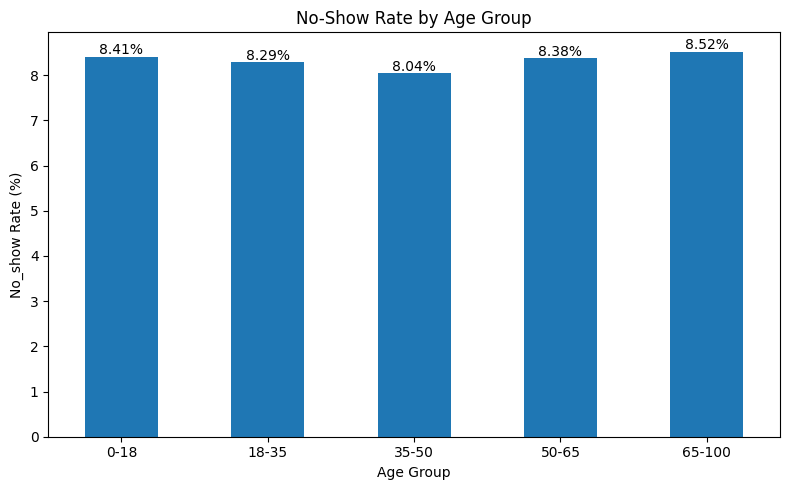

In [91]:
# No-show Rate (%) by Age Group
ans['1_pct'].plot(kind='bar', figsize=(8,5))

for i, v in enumerate(ans['1_pct']):
    plt.text(i,v + 0.05, f'{v:.2f}%', ha='center')
    
plt.title('No-Show Rate by Age Group')
plt.ylabel('No_show Rate (%)')
plt.xlabel('Age Group')
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

In [92]:
gns

no_show,0,1
gender,,
Female,91.57,8.43
Male,91.92,8.08
Other,91.26,8.74


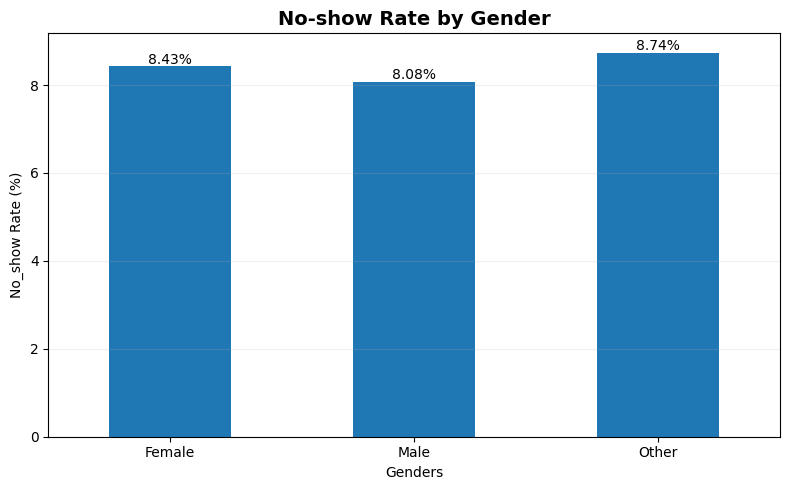

In [93]:
# No-show Rate (%) by Gender
ax = gns[1].plot(kind='bar', figsize=(8,5))

for i, v in enumerate(gns[1]):
    plt.text(i,v + 0.05,f'{v:.2f}%', ha='center')

plt.title('No-show Rate by Gender', fontsize=14, fontweight='bold')
plt.xlabel('Genders')
plt.xticks(rotation=0)
plt.ylabel('No_show Rate (%)')
plt.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

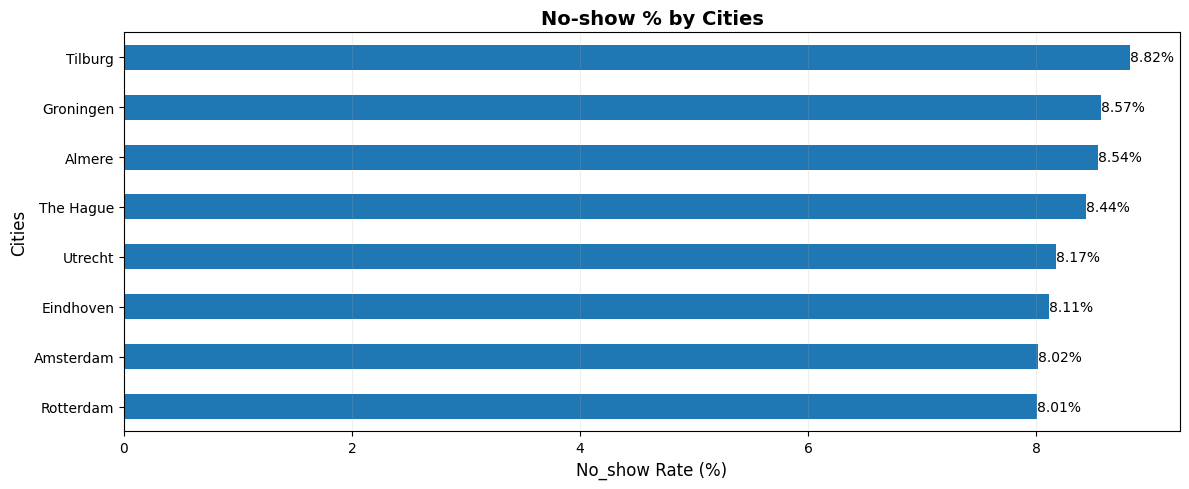

In [94]:
# No-show Rate (%) by Cities
ax = cns['1_pct'].sort_values().plot(kind='barh', figsize=(12,5))
for container in ax.containers:
    plt.bar_label(container, fmt='%.2f%%')

plt.title('No-show % by Cities', fontsize=14, fontweight='bold')
plt.xlabel('No_show Rate (%)', fontsize=12)
plt.ylabel('Cities', fontsize=12)
plt.grid(axis='x', alpha=0.2)
plt.tight_layout()

plt.show()

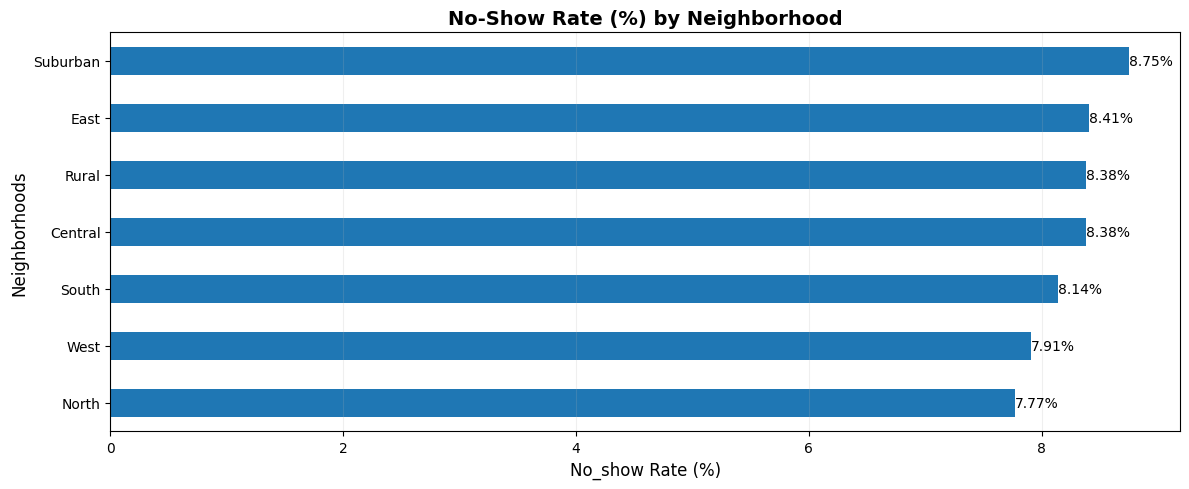

In [95]:
# No-Show Rate (%) by Neighborhood
ax = nns['1_pct'].sort_values(ascending=True).plot(kind='barh', figsize=(12,5))

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%')

plt.title('No-Show Rate (%) by Neighborhood', fontsize=14, fontweight='bold')
plt.xlabel('No_show Rate (%)', fontsize=12)
plt.ylabel('Neighborhoods', fontsize=12)
plt.grid(axis='x', alpha=0.2)
plt.tight_layout()

plt.show()

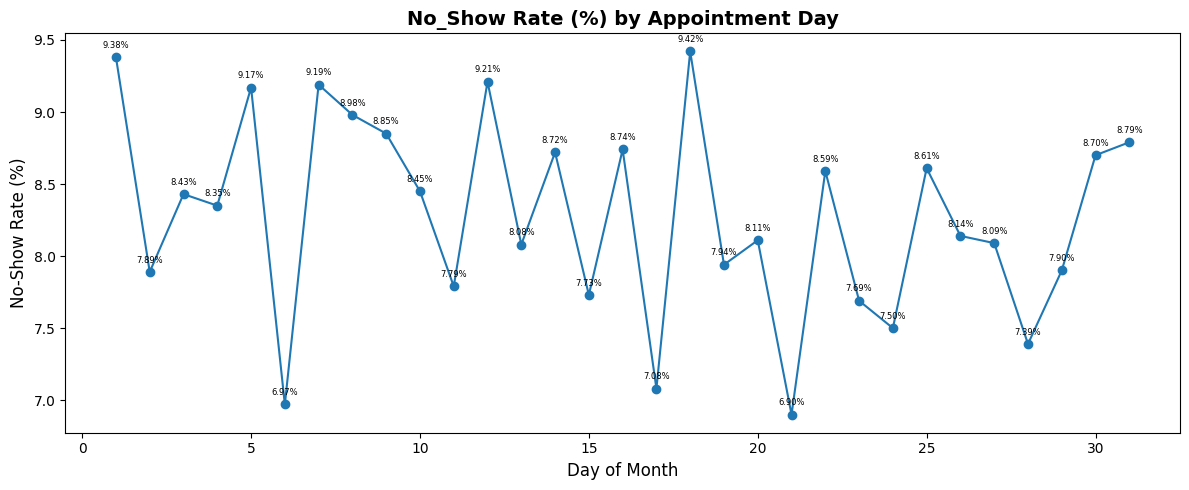

In [96]:
# No-Show Rate (%) by Appoint_day

ax = dns['1_pct'].plot(kind='line', marker='o', figsize=(12,5))

for i, v in enumerate(dns['1_pct']):
    plt.text(i+1,v + 0.065, f'{v:.2f}%', fontsize=6, ha='center')

plt.title('No_Show Rate (%) by Appointment Day', fontsize=14, fontweight='bold')
plt.xlabel('Day of Month', fontsize=12)
plt.ylabel('No-Show Rate (%)', fontsize=12)

plt.tight_layout()

plt.show()

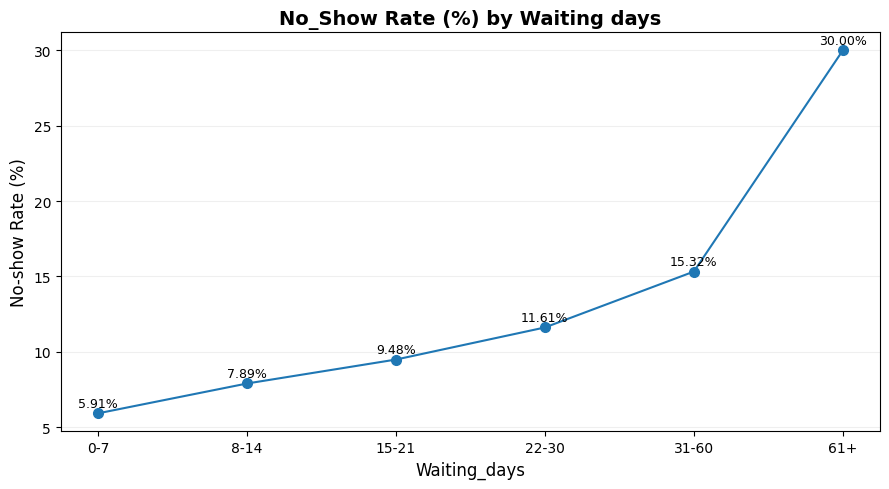

In [97]:
# No-Show Rate (%) by Waiting days
ax = wns[1].plot(kind='line', marker='o', markersize=7,figsize=(9,5))

for i, v in enumerate(wns[1]):
    plt.text(i, v + 0.45, f'{v:.2f}%',fontsize=9,  ha='center')

plt.title('No_Show Rate (%) by Waiting days', fontsize=14, fontweight='bold')
plt.xlabel('Waiting_days', fontsize=12)
plt.ylabel('No-show Rate (%)', fontsize=12)
plt.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

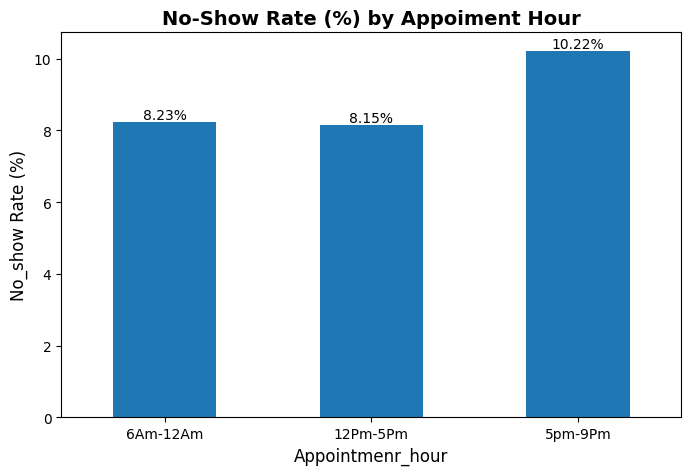

In [98]:
# No-Show Rate (%) by Appoiment Hour
ax = ahg['1_pct'].plot(kind='bar', figsize=(8,5))

for container in ax.containers:
    plt.bar_label(container, fmt='%.2f%%')

plt.title('No-Show Rate (%) by Appoiment Hour', fontsize=14, fontweight='bold')
plt.xlabel('Appointmenr_hour', fontsize=12)
plt.xticks(rotation=0)
plt.ylabel('No_show Rate (%)', fontsize=12)

plt.show()

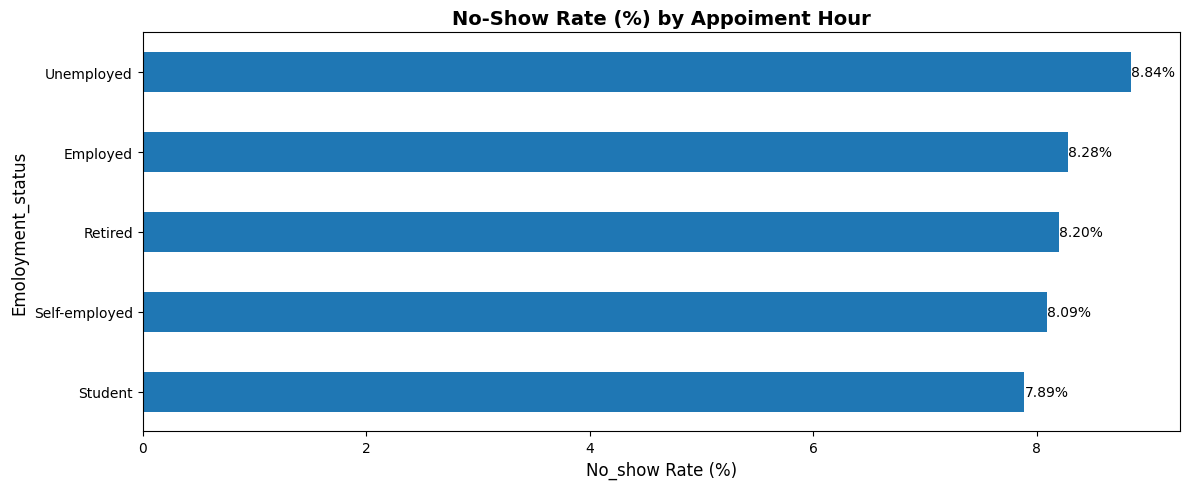

In [99]:
# No-Show Rate (%) by Emoloyment Status

ax = esns['1_pct'].sort_values(ascending=True).plot(kind='barh', figsize=(12,5))
for container in ax.containers:
    plt.bar_label(container, fmt='%.2f%%')

plt.title('No-Show Rate (%) by Appoiment Hour', fontsize=14, fontweight='bold')
plt.xlabel('No_show Rate (%)',fontsize=12)
plt.ylabel('Emoloyment_status', fontsize=12)
plt.tight_layout()


plt.show()

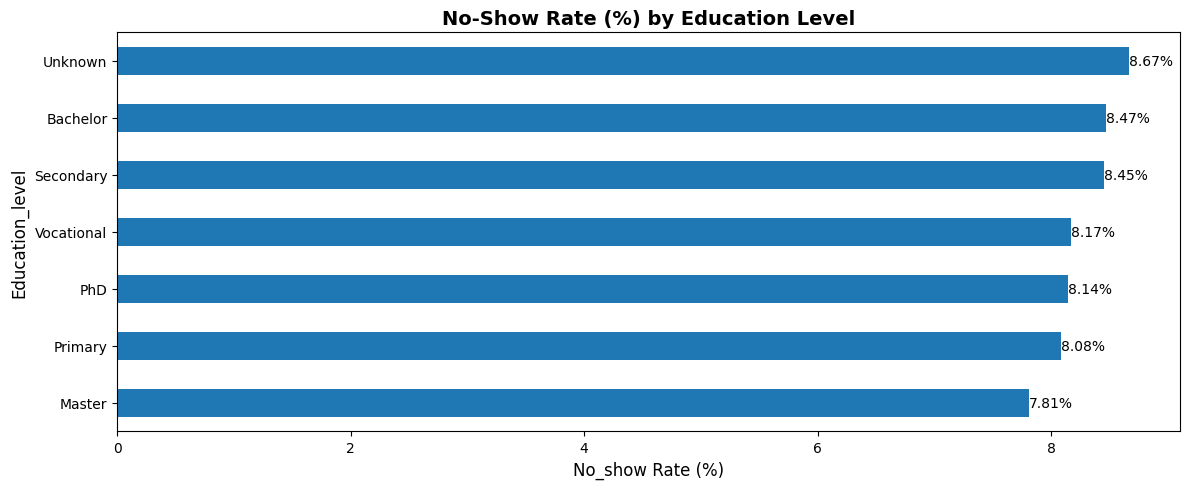

In [100]:
# No-Show Rate (%) by Education Level

ax = elns['1_pct'].sort_values(ascending=True).plot(kind='barh', figsize=(12,5))
for container in ax.containers:
    plt.bar_label(container, fmt='%.2f%%')

plt.title('No-Show Rate (%) by Education Level', fontsize=14, fontweight='bold')
plt.xlabel('No_show Rate (%)',fontsize=12)
plt.ylabel('Education_level', fontsize=12)
plt.tight_layout()


plt.show()

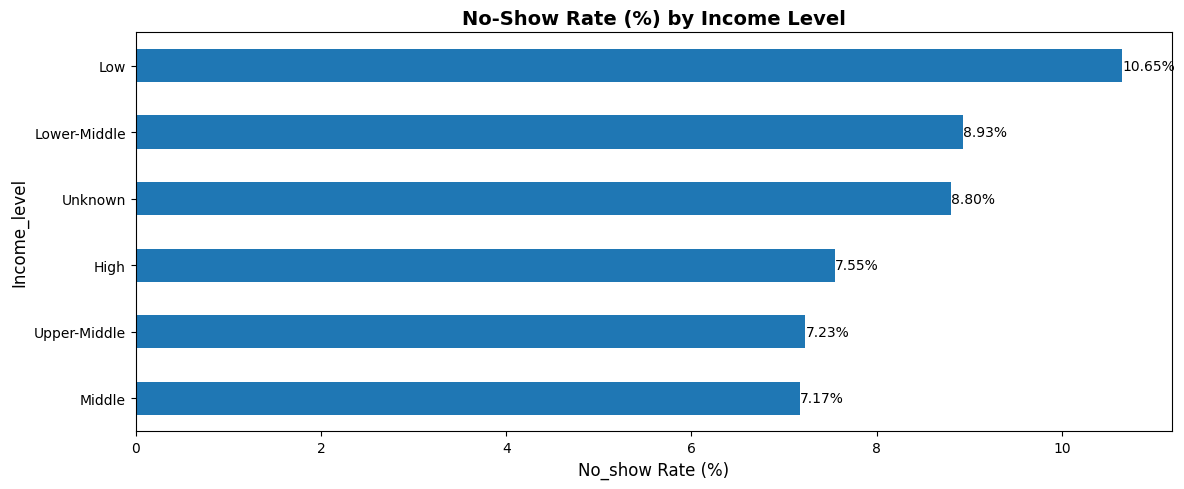

In [101]:
# No-Show Rate (%) by Income Level

ax = ilns['1_pct'].sort_values(ascending=True).plot(kind='barh', figsize=(12,5))
for container in ax.containers:
    plt.bar_label(container, fmt='%.2f%%')

plt.title('No-Show Rate (%) by Income Level', fontsize=14, fontweight='bold')
plt.xlabel('No_show Rate (%)',fontsize=12)
plt.ylabel('Income_level', fontsize=12)
plt.tight_layout()


plt.show()

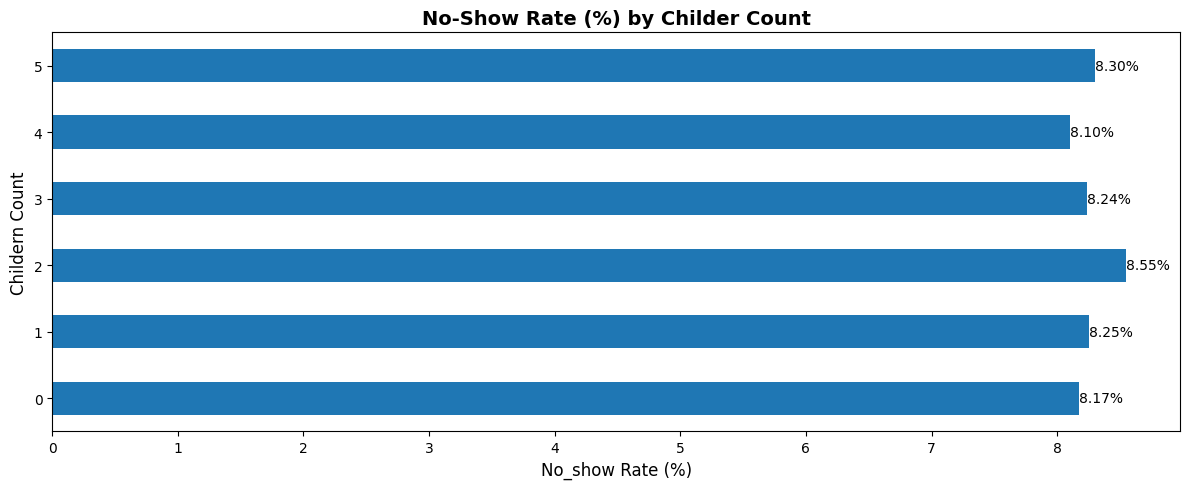

In [102]:
# No-Show Rate (%) by Childer Count

ax = ccns['1_pct'].sort_index(ascending=True).plot(kind='barh', figsize=(12,5))
for container in ax.containers:
    plt.bar_label(container, fmt='%.2f%%')

plt.title('No-Show Rate (%) by Childer Count', fontsize=14, fontweight='bold')
plt.xlabel('No_show Rate (%)',fontsize=12)
plt.ylabel('Childern Count', fontsize=12)
plt.tight_layout()


plt.show()

**Bivariate Patient Columns (Other factors) vs No_show**

In [104]:
pdf2

,day_of_week,month,sms_received,reminder_calls,previous_appointments,previous_no_shows,no_show_rate
0,Sunday,7,1,0,7,2,0.286
1,Wednesday,2,0,0,3,0,0.000
2,Monday,9,1,0,3,0,0.000
3,Sunday,2,1,3,3,1,0.333
4,Sunday,4,0,1,5,0,0.000
...,...,...,...,...,...,...,...
49995,Wednesday,12,1,2,7,0,0.000
49996,Monday,2,0,1,6,0,0.000
49997,Wednesday,6,1,2,6,4,0.667
49998,Thursday,7,1,2,5,0,0.000


In [145]:
downs = pd.crosstab(pdf2['day_of_week'], pdf['no_show'])
downs

no_show,0,1
day_of_week,,
Friday,6577,577
Monday,6539,611
Saturday,6482,556
Sunday,6627,599
Thursday,6470,610
Tuesday,6691,594
Wednesday,6476,591


In [124]:
print((6577/ 7154 ) * 100)
print((577 / 7154) * 100)

91.93458205199889
8.065417948001118


In [169]:
downss = (pd.crosstab(pdf2['day_of_week'], pdf['no_show'], normalize='index') * 100)
downs[['0_pct','1_pct']] = downss.round(2)
view_downs = downs.copy()
view_downs[['0_pct','1_pct']] = view_downs[['0_pct','1_pct']].astype(str) + '%'
week_sorter = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
view_downs.reindex(week_sorter)

no_show,0,1,0_pct,1_pct
day_of_week,,,,
Monday,6539,611,91.45%,8.55%
Tuesday,6691,594,91.85%,8.15%
Wednesday,6476,591,91.64%,8.36%
Thursday,6470,610,91.38%,8.62%
Friday,6577,577,91.93%,8.07%
Saturday,6482,556,92.1%,7.9%
Sunday,6627,599,91.71%,8.29%


**EDA-Visualization - Bivariate Patient Analysis Columns (other factors) Vs No_show**

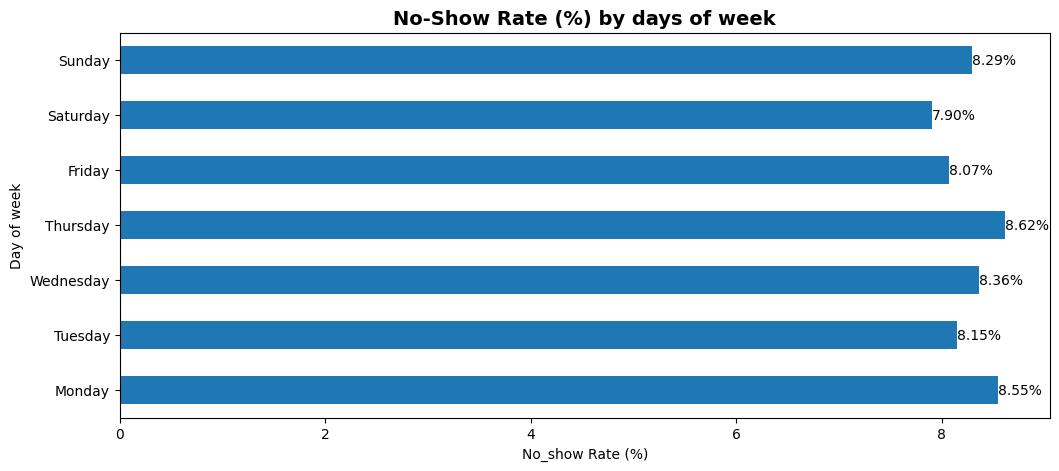

In [172]:
# No-Show Rate (%) by days of week
ax = downs['1_pct'].reindex(week_sorter).plot(kind='barh', figsize=(12,5))

for container in ax.containers:
    plt.bar_label(container, fmt='%.2f%%', fontsize=10)

plt.title('No-Show Rate (%) by days of week', fontsize=14, fontweight='bold')
plt.xlabel('No_show Rate (%)')
plt.ylabel('Day of week')

plt.show()
